# Time Series Forecasting - Exchange Rate

## Objective
To forecast exchange rates using ARIMA and Exponential Smoothing models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
df.columns = ['Date', 'Rate']

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M')

df = df.set_index('Date')
df = df.sort_index()

df.head()

,Rate
Date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


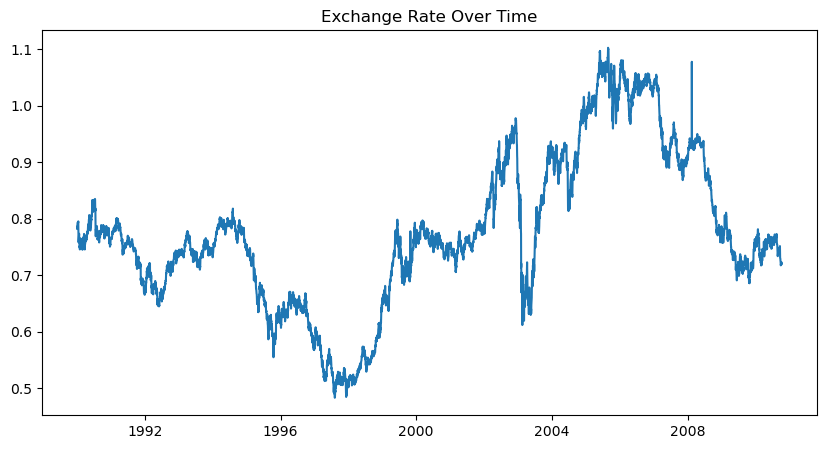

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df['Rate'])
plt.title("Exchange Rate Over Time")
plt.show()

## Time Series Analysis

- The exchange rate shows a clear trend, indicating non-stationarity.
- No strong seasonality is observed in the data.
- The series contains random fluctuations and sudden spikes.

Therefore, differencing is required before applying ARIMA.

In [5]:
df_diff = df.diff().dropna()

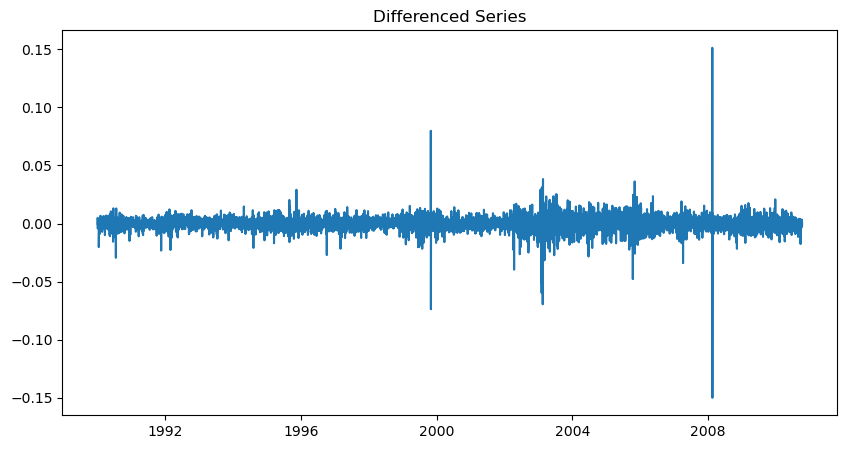

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df_diff['Rate'])
plt.title("Differenced Series")
plt.show()

## Stationarity Check

After applying first-order differencing:
- The trend has been removed.
- The series fluctuates around zero.
- Variance appears stable over time.

Thus, the series is approximately stationary and suitable for ARIMA modeling with d = 1.

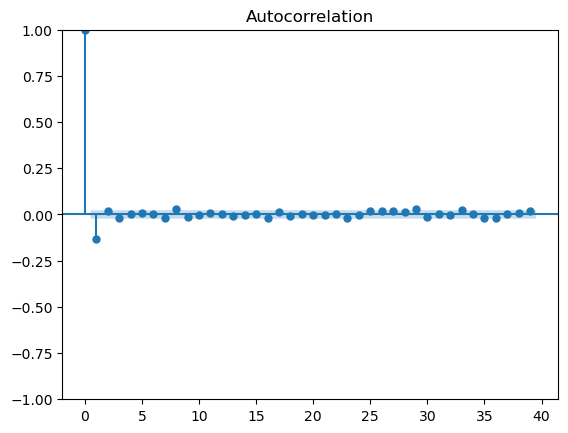

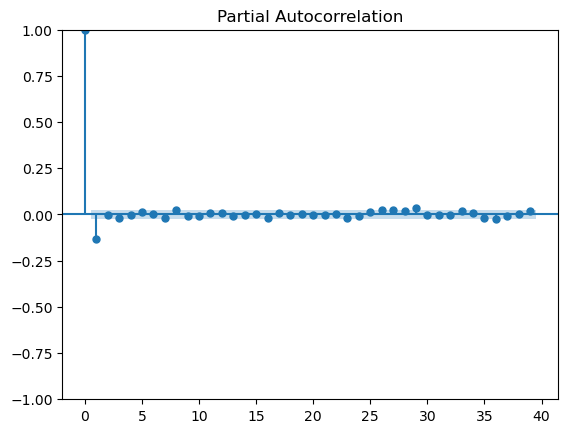

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff['Rate'])
plot_pacf(df_diff['Rate'])
plt.show()

## ARIMA Parameter Selection

- ACF shows a significant spike at lag 1 and then cuts off.
- PACF also shows a significant spike at lag 1.

Thus, the selected model is ARIMA(1,1,1).

In [8]:
model = ARIMA(df['Rate'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   Rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Mon, 04 May 2026   AIC                         -56102.322
Time:                        18:20:17   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


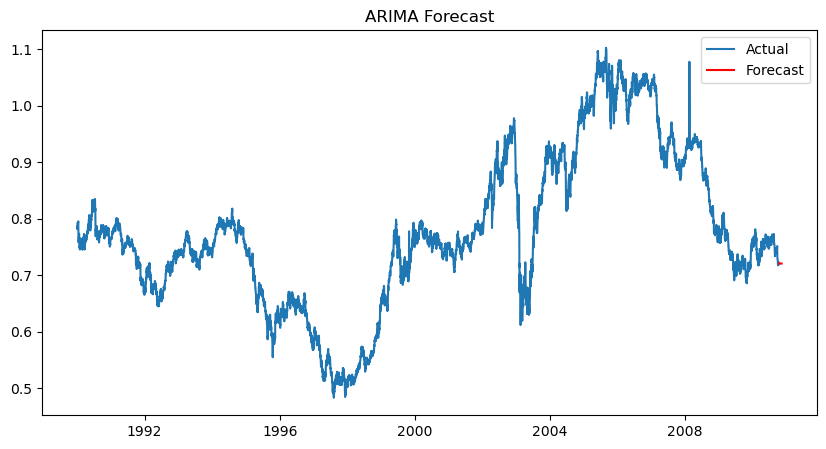

In [9]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df['Rate'], label='Actual')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

## ARIMA Model Evaluation

The ARIMA model produces a relatively smooth forecast that follows the general direction of the series.

However:
- The forecast lacks responsiveness to sudden fluctuations.
- It behaves like a random-walk model.

Thus, ARIMA captures the overall trend but struggles with short-term volatility.

In [10]:
model_exp = ExponentialSmoothing(df['Rate'], trend='add')
model_exp_fit = model_exp.fit()

C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


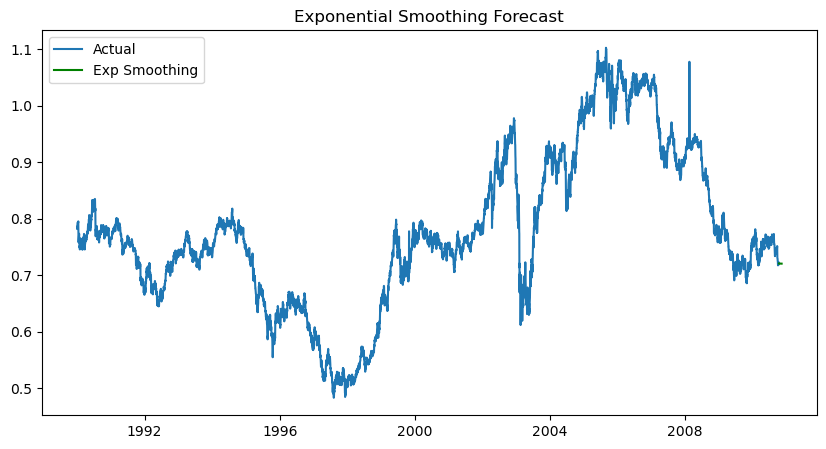

In [11]:
forecast_exp = model_exp_fit.forecast(30)

plt.figure(figsize=(10,5))
plt.plot(df['Rate'], label='Actual')
plt.plot(forecast_exp, label='Exp Smoothing', color='green')
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

## Exponential Smoothing Evaluation

The Exponential Smoothing model produces a smoother forecast that follows the recent trend slightly better than ARIMA.

However:
- It still fails to capture sudden fluctuations.
- The model smooths out volatility, leading to less accurate predictions during sharp movements.

In [12]:
train = df.iloc[:-30]
test = df.iloc[-30:]

In [13]:
model_arima = ARIMA(train['Rate'], order=(1,1,1)).fit()
pred_arima = model_arima.forecast(30)

C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [14]:
model_exp = ExponentialSmoothing(train['Rate'], trend='add').fit()
pred_exp = model_exp.forecast(30)

C:\Users\rajur\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

arima_metrics = evaluate(test['Rate'], pred_arima)
exp_metrics = evaluate(test['Rate'], pred_exp)

print("ARIMA:", arima_metrics)
print("Exp Smoothing:", exp_metrics)

ARIMA: (0.013494600805886207, np.float64(0.016632177913116195), np.float64(1.8632207485601178))
Exp Smoothing: (0.013423166021854727, np.float64(0.016495942324613804), np.float64(1.8531561149080686))


## Model Evaluation and Comparison

The performance of both models is very similar:

- ARIMA: MAE = 0.01349, RMSE = 0.01663, MAPE = 1.86%
- Exponential Smoothing: MAE = 0.01342, RMSE = 0.01649, MAPE = 1.85%

Exponential Smoothing performs slightly better across all metrics.

However, the difference is minimal, indicating that both models are comparable in performance.

Both models struggle to capture sudden fluctuations due to the volatile nature of exchange rate data.

## Conclusion

- The exchange rate series is non-stationary and required differencing for ARIMA modeling.
- ARIMA(1,1,1) provided stable but less responsive forecasts.
- Exponential Smoothing captured recent trends slightly better.

Overall, Exponential Smoothing performed marginally better than ARIMA.

However, both models have limitations in handling volatility in financial time series.